### [Profitable Pairs Trading Strategy](https://medium.com/coding-nexus/781e91450e27)

> Simple StatArb Strategy


Pairs trading uses statistical relationships between two stocks to identify mean-reversion opportunities.

Typically take a long position in one and a short in the other, betting that their price spread will revert to its historical mean. But correlation alone isn’t enough to cut it.

In [1]:
# Install required packages (only if missing)
# In Colab, this should take ~30 seconds

import subprocess
import sys

def install_if_missing(package, import_name=None):
    """Install package if not already available."""
    import_name = import_name or package.split('[')[0]  # handle extras like langchain[google]
    try:
        __import__(import_name.replace('-', '_'))
    except ImportError:
        print(f"Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

install_if_missing("yfinance")
print("✓ All packages ready!")

✓ All packages ready!


In [2]:
import os, sys
import numpy as np
import pandas as pd
import seaborn as sns
import yfinance as yf
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import coint

from IPython.display import display

np.set_printoptions(suppress=True, precision=4)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

plt.style.use('fivethirtyeight')
plt.rcParams['figure.figsize'] = (12, 10)

import warnings
warnings.filterwarnings('ignore')

In [3]:
tickers = ["NEE", "FSLR", "ENPH", "PLUG", "BEP", "AQN", "PBW", "FAN", "ICLN"]
start_date = "2015-01-01"
end_date = "2025-01-01"
df = yf.download(tickers, start=start_date, end=end_date, progress=False).Close.dropna()

display(df.sample(15))

Ticker,AQN,BEP,ENPH,FAN,FSLR,ICLN,NEE,PBW,PLUG
Date,,,,,,,,,
2022-06-13,11.2673,29.5683,178.2400,16.3898,63.1300,17.5145,65.7051,43.3165,14.2000
2021-07-28,12.1799,32.6388,181.4200,19.9261,83.4800,21.4255,69.2296,74.3400,27.8300
2024-05-07,6.1784,24.4948,114.9300,15.7517,194.6700,13.4859,68.4198,21.0755,2.6400
2022-12-15,6.1003,23.5464,314.0600,16.6733,159.4100,19.7820,78.6392,39.8365,14.4200
2015-03-09,3.9712,9.2843,14.1800,8.3496,61.0600,9.4662,18.7116,22.3818,2.9100
2020-12-30,12.7450,34.5213,172.9300,21.6218,100.3400,26.4024,66.7990,93.4460,34.1900
2024-05-28,5.9544,25.7962,129.3800,16.8810,280.1600,14.5679,73.7261,22.2501,3.2500
2023-11-01,4.7479,19.4544,76.7300,12.9831,142.8400,12.3343,54.6148,23.6311,5.7500
2015-04-02,4.4019,10.3066,13.3600,8.6366,61.1900,9.9081,19.8124,22.8293,2.5600


In [4]:
n = len(tickers)
score_matrix = np.zeros((n, n))
pvalue_matrix = np.ones((n, n))
pairs = []

for i in range(n):
    for j in range(i + 1, n):
        score, pval, _ = coint(df.iloc[:, i], df.iloc[:, j])
        score_matrix[i, j] = score
        pvalue_matrix[i, j] = pval
        if pval < 0.10:
            pairs.append((tickers[i], tickers[j]))
print(f"Total pairs: {len(pairs)}")

Total pairs: 3


In [5]:
mask = np.triu(np.ones_like(pvalue_matrix, dtype=bool), k=1)
upper_vals = pvalue_matrix[mask]
min_idx_flat = np.argmin(upper_vals)
idx_pairs = np.column_stack(np.where(mask))
i, j = idx_pairs[min_idx_flat]
S1, S2 = df.iloc[:, i], df.iloc[:, j]
spread = S1 - S2
zscore = (spread - spread.rolling(21).mean()) / spread.rolling(21).std()
print(f"Lowest p-value pair: {tickers[i]} x {tickers[j]}")

Lowest p-value pair: FAN x ICLN


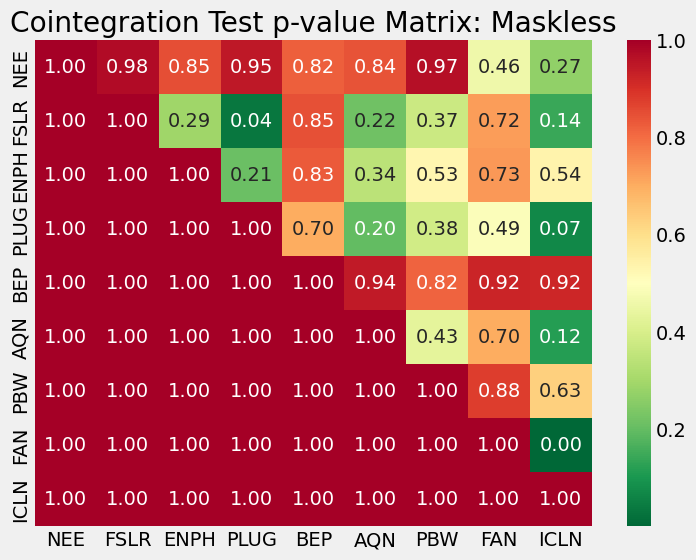

In [6]:
plt.figure(figsize=(8, 6))
sns.heatmap(
    pvalue_matrix,
    xticklabels=tickers,
    yticklabels=tickers,
    cmap="RdYlGn_r",
    annot=True,
    fmt=".2f",
)
plt.title("Cointegration Test p-value Matrix: Maskless")
plt.show()

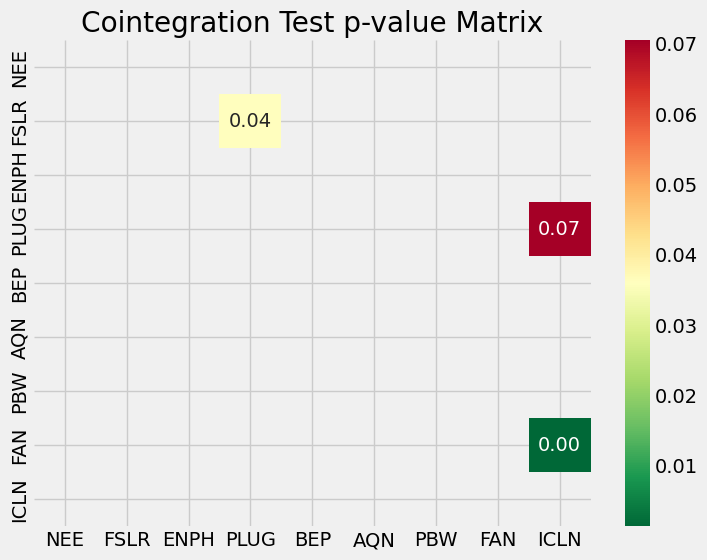

In [7]:
mask = np.tril(np.ones_like(pvalue_matrix, dtype=bool)) | (pvalue_matrix >= 0.10)
plt.figure(figsize=(8, 6))
sns.heatmap(
    pvalue_matrix,
    mask=mask,
    xticklabels=tickers,
    yticklabels=tickers,
    cmap="RdYlGn_r",
    annot=True,
    fmt=".2f",
)
plt.title("Cointegration Test p-value Matrix")
plt.show()

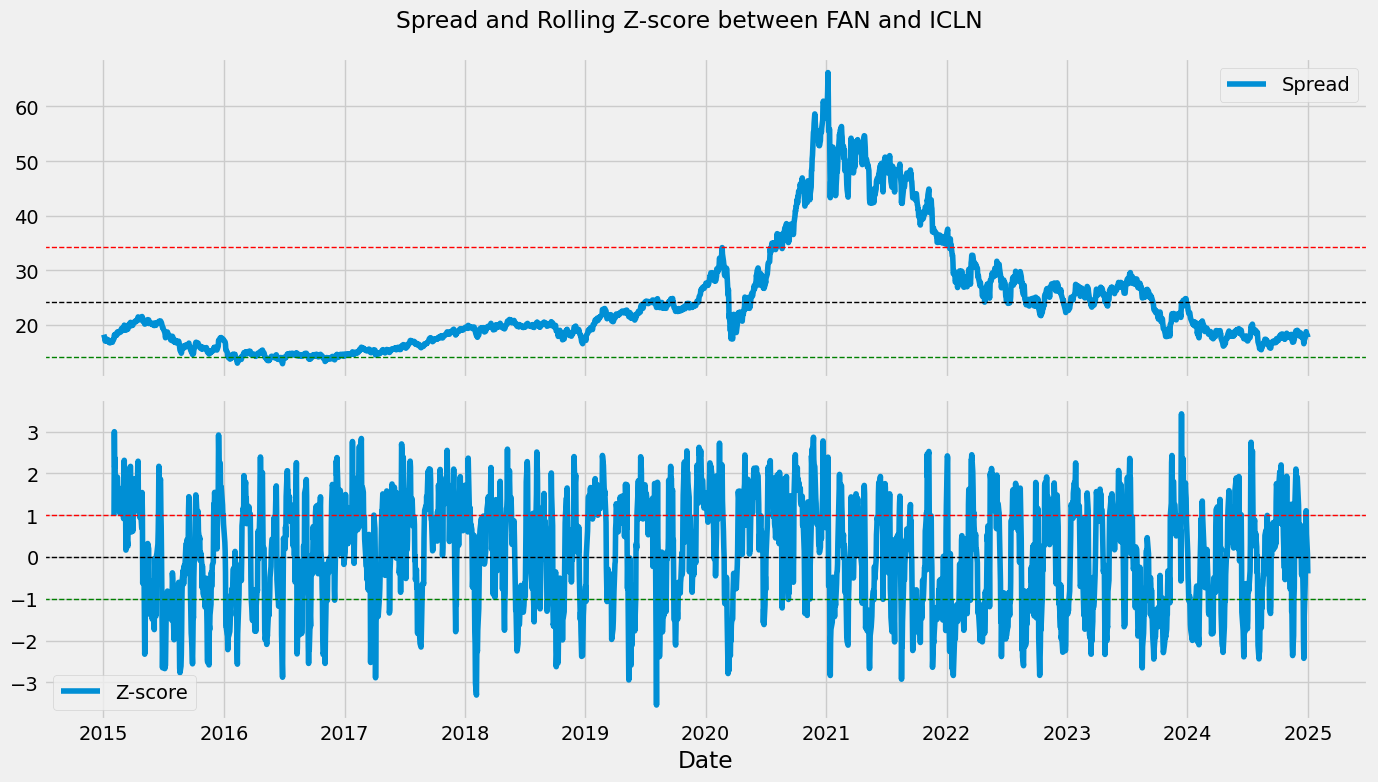

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(spread.index, spread, label="Spread")
axes[0].axhline(spread.mean(), color="black", linestyle="--", lw=1)
axes[0].axhline(spread.mean() + spread.std(), color="red", linestyle="--", lw=1)
axes[0].axhline(spread.mean() - spread.std(), color="green", linestyle="--", lw=1)
axes[0].legend()
axes[1].plot(zscore.index, zscore, label="Z-score")
axes[1].axhline(0, color="black", linestyle="--", lw=1)
axes[1].axhline(1, color="red", linestyle="--", lw=1)
axes[1].axhline(-1, color="green", linestyle="--", lw=1)
axes[1].legend()

plt.xlabel("Date")
plt.suptitle(f"Spread and Rolling Z-score between {tickers[i]} and {tickers[j]}")
plt.tight_layout()
plt.show()